# OpenMC vs MCNP plasma source comparison

Plots the neutron flux and relative error on XY / XZ slices for both codes, their ratio,
and performs a voxel-wise t-test against the acceptance criteria of section 7.3.

# OpenMC vs MCNP plasma source comparison

Plots the neutron flux and relative error on XY / XZ slices for both codes, their ratio,
and performs a voxel-wise t-test against the acceptance criteria of section 7.3.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import openmc
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [ ]:
# !cd openmc_run && openmc 

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [3]:
openmc_sp_file = 'openmc_run/statepoint.1000.h5'
tally_name = 'Nflux'

mcnp_h5_file = 'mcnp_run/c_source-batch.h5'
mcnp_tally_key = 'mesh_tally_4'

# Slice coordinates [cm] - nearest voxel centre is used
xy_z = 0.0
xz_y = 0.0

flux_vmin, flux_vmax, flux_n_colors = 1e-7, 1e-5, 256
err_vmin, err_vmax = 0.0, 1.0            # [%]
ratio_vmin, ratio_vmax, ratio_n_colors = 0.80, 1.20, 20

In [4]:
def plot_slice(xc, yc, values, label, xlabel, ylabel, fname,
               norm=None, cmap='jet', vmin=None, vmax=None, title=None):
    fig, ax = plt.subplots(figsize=(9, 7))
    if norm is not None:
        im = ax.pcolormesh(xc, yc, values, norm=norm, cmap=cmap)
    else:
        im = ax.pcolormesh(xc, yc, values, vmin=vmin, vmax=vmax, cmap=cmap)
    cax = make_axes_locatable(ax).append_axes('right', size='5%', pad=0.1)
    fig.colorbar(im, cax=cax, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect('equal')
    if title:
        ax.set_title(title)
    fig.tight_layout()
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname}')
    plt.show()


def flux_norm():
    return plt.matplotlib.colors.LogNorm(vmin=flux_vmin, vmax=flux_vmax)


flux_cmap = plt.get_cmap('jet', flux_n_colors)
ratio_cmap = plt.get_cmap('jet', ratio_n_colors)

## Load data

In [5]:
sp = openmc.StatePoint(openmc_sp_file)
tally = sp.get_tally(name=tally_name)
mesh = next(f for f in tally.filters if isinstance(f, openmc.MeshFilter)).mesh

nx, ny, nz = mesh.dimension
dx, dy, dz = (np.asarray(mesh.upper_right) - np.asarray(mesh.lower_left)) / (nx, ny, nz)
voxel_volume = dx * dy * dz

x_centers = mesh.lower_left[0] + (np.arange(nx) + 0.5) * dx
y_centers = mesh.lower_left[1] + (np.arange(ny) + 0.5) * dy
z_centers = mesh.lower_left[2] + (np.arange(nz) + 0.5) * dz

# OpenMC orders mesh bins z-slowest, x-fastest
openmc_flux = tally.get_values(scores=['flux'], value='mean').reshape(nz, ny, nx) / voxel_volume
openmc_rse = np.nan_to_num(
    tally.get_values(scores=['flux'], value='rel_err').reshape(nz, ny, nx), nan=0.0)

iz = int(np.argmin(np.abs(z_centers - xy_z)))
iy = int(np.argmin(np.abs(y_centers - xz_y)))

print(f'OpenMC grid: {nx} x {ny} x {nz} voxels of {voxel_volume:.3f} cm3')
print(f'Slices: iz={iz} (z={z_centers[iz]:.2f} cm), iy={iy} (y={y_centers[iy]:.2f} cm)')

OpenMC grid: 50 x 60 x 90 voxels of 1000.000 cm3
Slices: iz=39 (z=-5.00 cm), iy=29 (y=-5.00 cm)


/home/kosbor/miniconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/tallies.py:1859: RuntimeWarning: invalid value encountered in divide
  data = self.std_dev[indices] / self.mean[indices]


In [6]:
# MCNP meshtal arrays are stored as (nz, ny, nx), matching the OpenMC layout
with h5py.File(mcnp_h5_file, 'r') as f:
    mt = f[f'results/mesh_tally/{mcnp_tally_key}']
    mcnp_comment = mt['comment_lines_1'][()].decode().strip()
    mcnp_grid_x = mt['grid_x'][()]
    mcnp_grid_y = mt['grid_y'][()]
    mcnp_grid_z = mt['grid_z'][()]
    mcnp_flux = mt['mean'][()][0, 0].copy()
    mcnp_rse = mt['relative_standard_error'][()][0, 0].copy()

mcnp_x_centers = 0.5 * (mcnp_grid_x[:-1] + mcnp_grid_x[1:])
mcnp_y_centers = 0.5 * (mcnp_grid_y[:-1] + mcnp_grid_y[1:])
mcnp_z_centers = 0.5 * (mcnp_grid_z[:-1] + mcnp_grid_z[1:])

mcnp_iz = int(np.argmin(np.abs(mcnp_z_centers - xy_z)))
mcnp_iy = int(np.argmin(np.abs(mcnp_y_centers - xz_y)))

print(f'MCNP tally {mcnp_tally_key!r} ({mcnp_comment})')
print(f'Grid: {mcnp_flux.shape[2]} x {mcnp_flux.shape[1]} x {mcnp_flux.shape[0]} voxels')
print(f'Slices: iz={mcnp_iz} (z={mcnp_z_centers[mcnp_iz]:.2f} cm), '
      f'iy={mcnp_iy} (y={mcnp_y_centers[mcnp_iy]:.2f} cm)')

MCNP tally 'mesh_tally_4' (Rectangular mesh tally)
Grid: 50 x 60 x 90 voxels
Slices: iz=39 (z=-5.00 cm), iy=29 (y=-5.00 cm)


## OpenMC

Saved: OpenMC_Nflux_XY_z-5.00cm.png


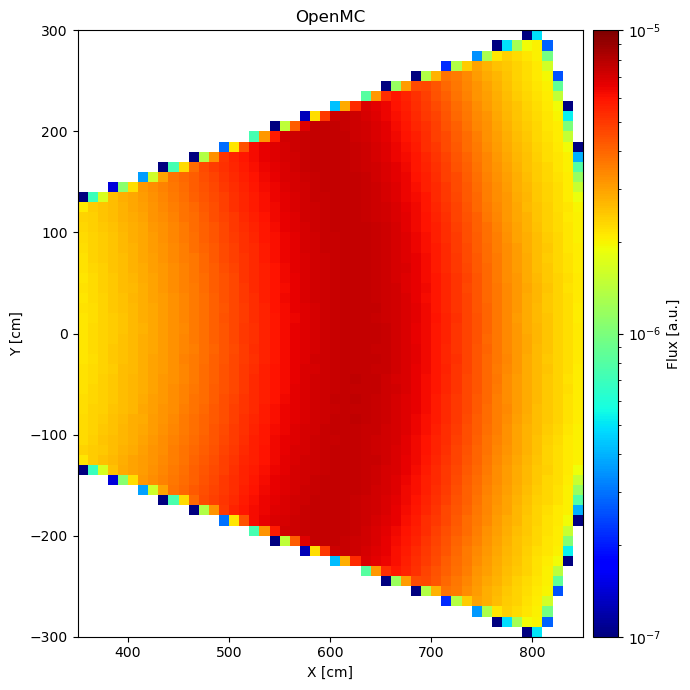

Saved: OpenMC_Nflux_RelErr_XY_z-5.00cm.png


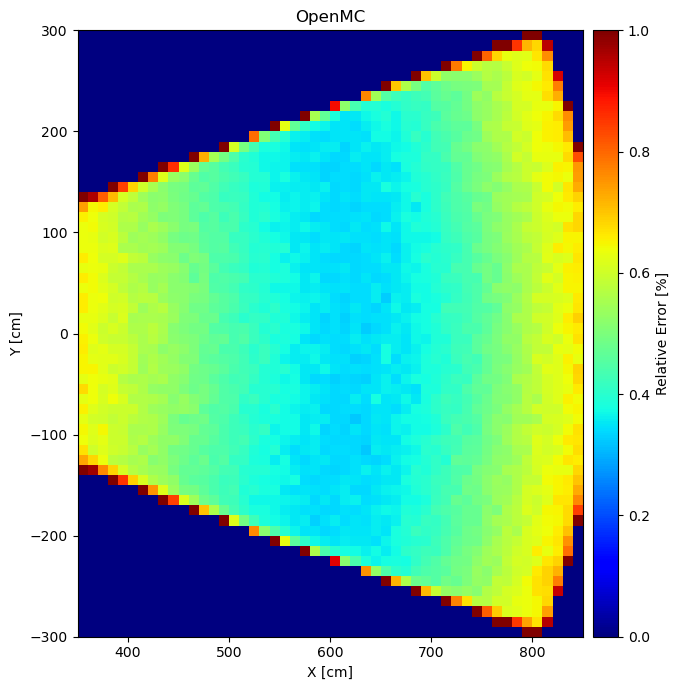

In [7]:
plot_slice(x_centers, y_centers, openmc_flux[iz], 'Flux [a.u.]', 'X [cm]', 'Y [cm]',
           f'OpenMC_{tally_name}_XY_z{z_centers[iz]:+.2f}cm.png',
           norm=flux_norm(), cmap=flux_cmap, title='OpenMC')

plot_slice(x_centers, y_centers, openmc_rse[iz] * 100, 'Relative Error [%]', 'X [cm]', 'Y [cm]',
           f'OpenMC_{tally_name}_RelErr_XY_z{z_centers[iz]:+.2f}cm.png',
           vmin=err_vmin, vmax=err_vmax, title='OpenMC')

Saved: OpenMC_Nflux_XZ_y-5.00cm.png


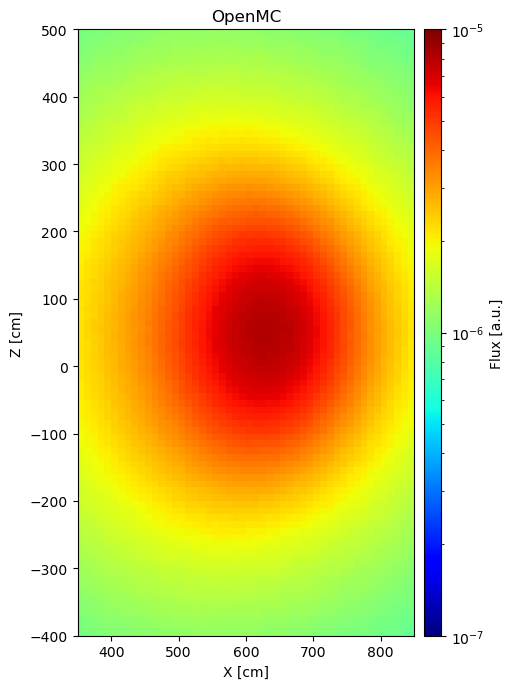

Saved: OpenMC_Nflux_RelErr_XZ_y-5.00cm.png


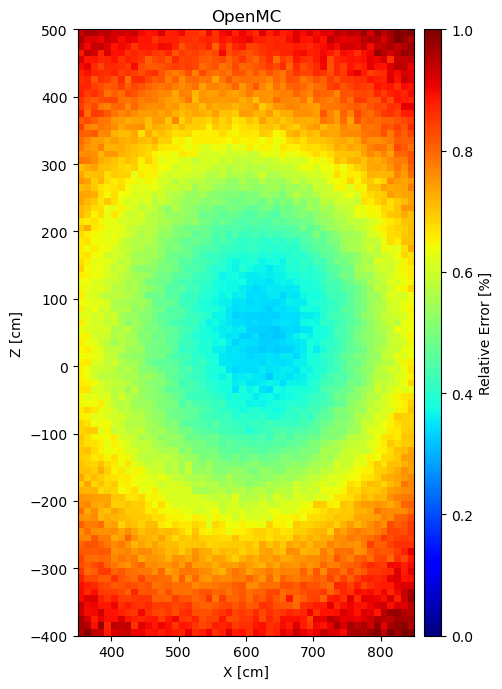

In [8]:
plot_slice(x_centers, z_centers, openmc_flux[:, iy, :], 'Flux [a.u.]', 'X [cm]', 'Z [cm]',
           f'OpenMC_{tally_name}_XZ_y{y_centers[iy]:+.2f}cm.png',
           norm=flux_norm(), cmap=flux_cmap, title='OpenMC')

plot_slice(x_centers, z_centers, openmc_rse[:, iy, :] * 100, 'Relative Error [%]', 'X [cm]', 'Z [cm]',
           f'OpenMC_{tally_name}_RelErr_XZ_y{y_centers[iy]:+.2f}cm.png',
           vmin=err_vmin, vmax=err_vmax, title='OpenMC')

## MCNP

Saved: MCNP_mesh_tally_4_XY_z-5.00cm.png


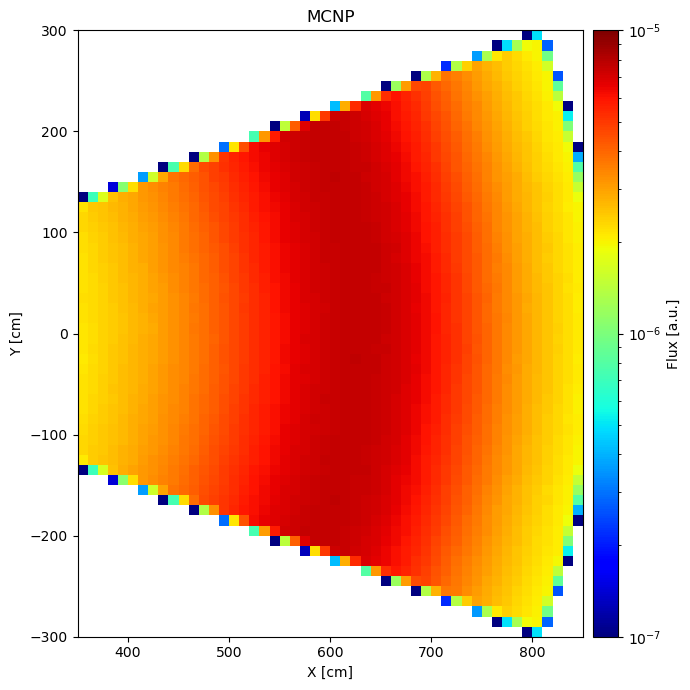

Saved: MCNP_mesh_tally_4_RelErr_XY_z-5.00cm.png


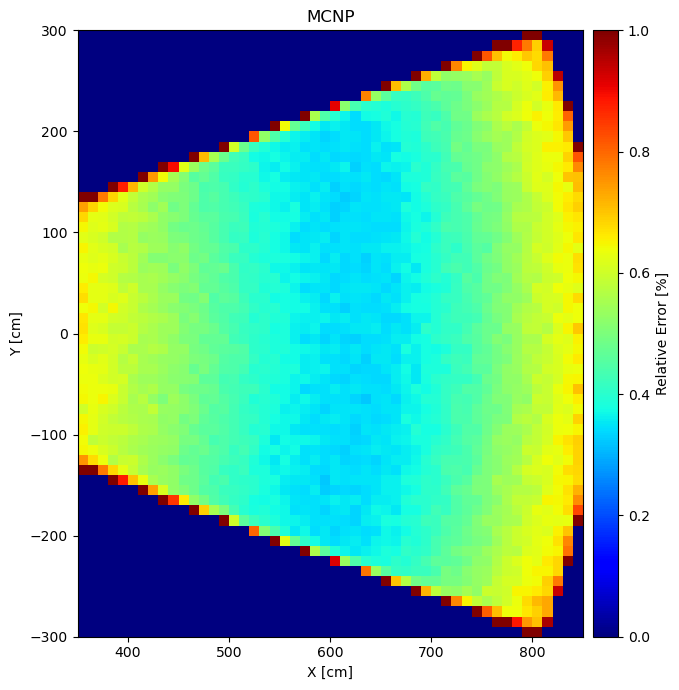

In [9]:
plot_slice(mcnp_x_centers, mcnp_y_centers, mcnp_flux[mcnp_iz], 'Flux [a.u.]', 'X [cm]', 'Y [cm]',
           f'MCNP_{mcnp_tally_key}_XY_z{mcnp_z_centers[mcnp_iz]:+.2f}cm.png',
           norm=flux_norm(), cmap=flux_cmap, title='MCNP')

plot_slice(mcnp_x_centers, mcnp_y_centers, mcnp_rse[mcnp_iz] * 100, 'Relative Error [%]', 'X [cm]', 'Y [cm]',
           f'MCNP_{mcnp_tally_key}_RelErr_XY_z{mcnp_z_centers[mcnp_iz]:+.2f}cm.png',
           vmin=err_vmin, vmax=err_vmax, title='MCNP')

Saved: MCNP_mesh_tally_4_XZ_y-5.00cm.png


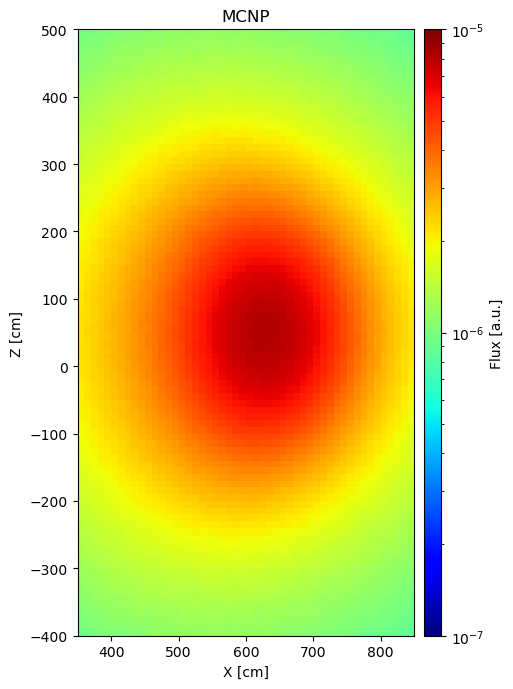

Saved: MCNP_mesh_tally_4_RelErr_XZ_y-5.00cm.png


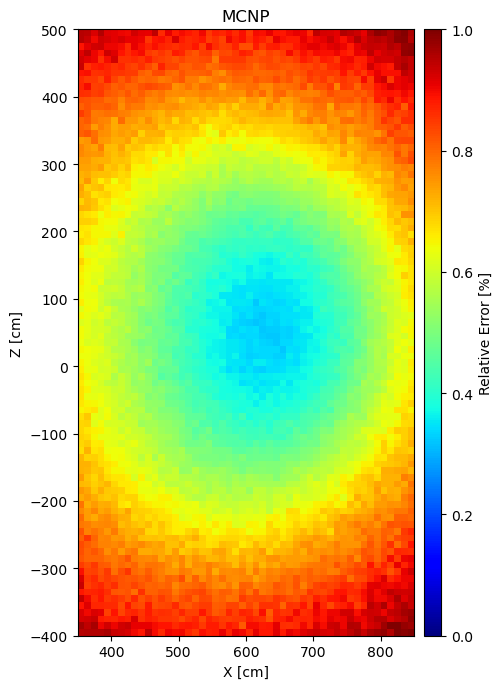

In [10]:
plot_slice(mcnp_x_centers, mcnp_z_centers, mcnp_flux[:, mcnp_iy, :], 'Flux [a.u.]', 'X [cm]', 'Z [cm]',
           f'MCNP_{mcnp_tally_key}_XZ_y{mcnp_y_centers[mcnp_iy]:+.2f}cm.png',
           norm=flux_norm(), cmap=flux_cmap, title='MCNP')

plot_slice(mcnp_x_centers, mcnp_z_centers, mcnp_rse[:, mcnp_iy, :] * 100, 'Relative Error [%]', 'X [cm]', 'Z [cm]',
           f'MCNP_{mcnp_tally_key}_RelErr_XZ_y{mcnp_y_centers[mcnp_iy]:+.2f}cm.png',
           vmin=err_vmin, vmax=err_vmax, title='MCNP')

## MCNP / OpenMC ratio

Saved: Ratio_Nflux_XY_z-5.00cm.png


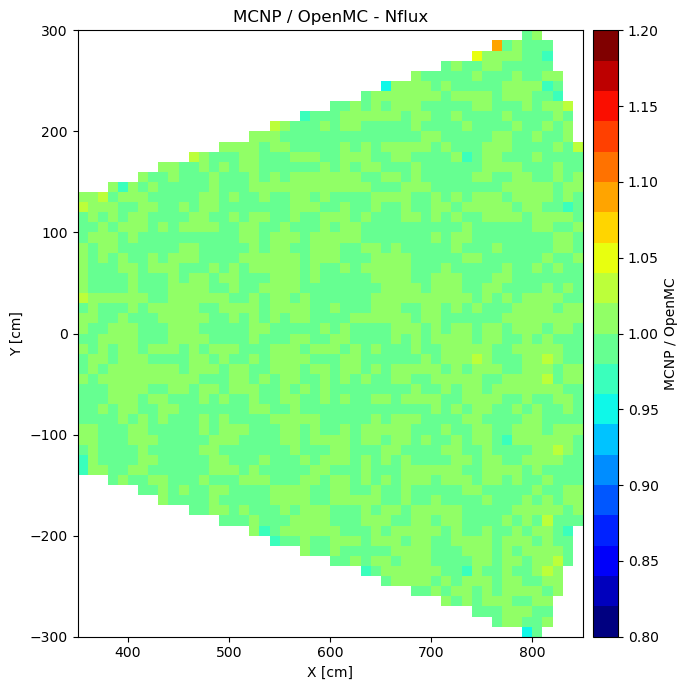

Saved: Ratio_Nflux_RelErr_XY_z-5.00cm.png


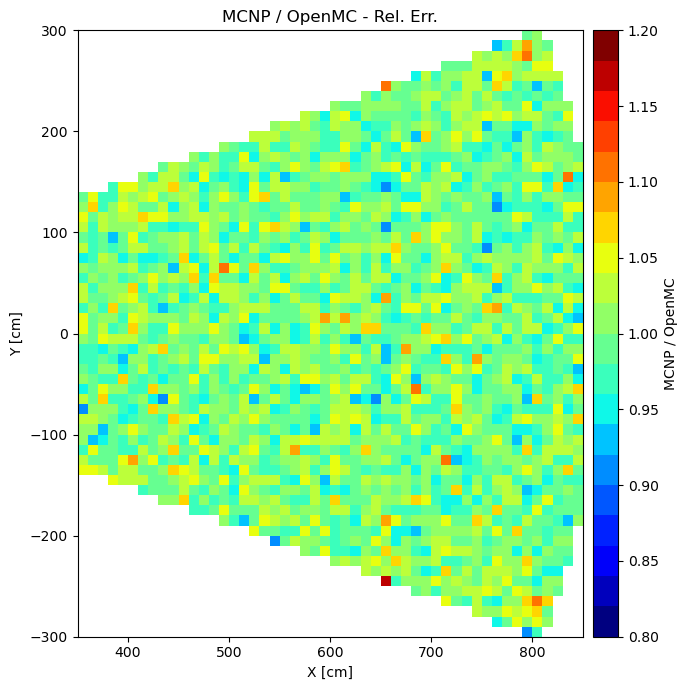

In [11]:
def ratio(num, den):
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(den > 0, num / den, np.nan)


plot_slice(x_centers, y_centers, ratio(mcnp_flux[mcnp_iz], openmc_flux[iz]),
           'MCNP / OpenMC', 'X [cm]', 'Y [cm]',
           f'Ratio_{tally_name}_XY_z{z_centers[iz]:+.2f}cm.png',
           vmin=ratio_vmin, vmax=ratio_vmax, cmap=ratio_cmap, title=f'MCNP / OpenMC - {tally_name}')

plot_slice(x_centers, y_centers, ratio(mcnp_rse[mcnp_iz], openmc_rse[iz]),
           'MCNP / OpenMC', 'X [cm]', 'Y [cm]',
           f'Ratio_{tally_name}_RelErr_XY_z{z_centers[iz]:+.2f}cm.png',
           vmin=ratio_vmin, vmax=ratio_vmax, cmap=ratio_cmap, title='MCNP / OpenMC - Rel. Err.')

Saved: Ratio_Nflux_XZ_y-5.00cm.png


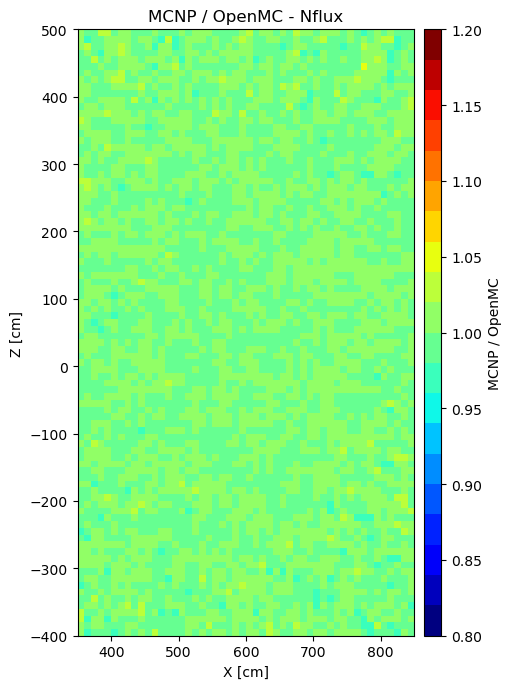

Saved: Ratio_Nflux_RelErr_XZ_y-5.00cm.png


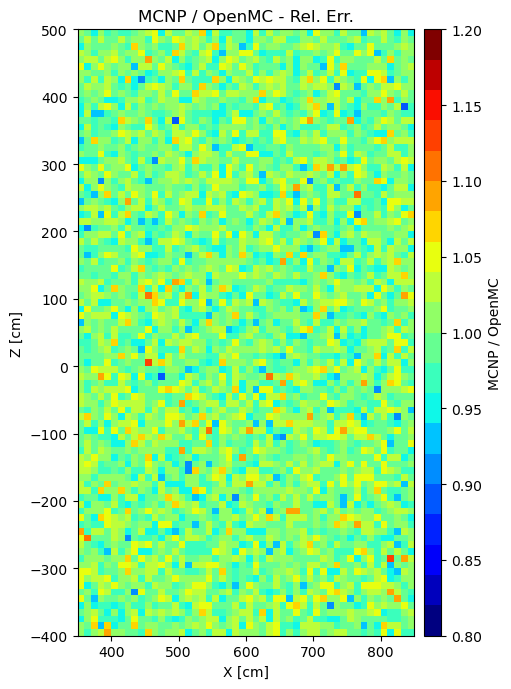

In [12]:
plot_slice(x_centers, z_centers, ratio(mcnp_flux[:, mcnp_iy, :], openmc_flux[:, iy, :]),
           'MCNP / OpenMC', 'X [cm]', 'Z [cm]',
           f'Ratio_{tally_name}_XZ_y{y_centers[iy]:+.2f}cm.png',
           vmin=ratio_vmin, vmax=ratio_vmax, cmap=ratio_cmap, title=f'MCNP / OpenMC - {tally_name}')

plot_slice(x_centers, z_centers, ratio(mcnp_rse[:, mcnp_iy, :], openmc_rse[:, iy, :]),
           'MCNP / OpenMC', 'X [cm]', 'Z [cm]',
           f'Ratio_{tally_name}_RelErr_XZ_y{y_centers[iy]:+.2f}cm.png',
           vmin=ratio_vmin, vmax=ratio_vmax, cmap=ratio_cmap, title='MCNP / OpenMC - Rel. Err.')

## Quantitative evaluation (section 7.3 acceptance criteria)

In [13]:
rse_cutoff = 0.10   # only score voxels converged to better than 10% in both codes
t_crit = 1.965       # two-sided, 5% significance
pass_fraction = 0.95

assert openmc_flux.shape == mcnp_flux.shape, 'OpenMC and MCNP meshes differ'

sigma_openmc = openmc_flux * openmc_rse
sigma_mcnp = mcnp_flux * mcnp_rse
denom = np.sqrt(sigma_openmc**2 + sigma_mcnp**2)

converged = (
    (openmc_flux > 0) & (mcnp_flux > 0) & (denom > 0)
    & (openmc_rse > 0) & (openmc_rse < rse_cutoff)
    & (mcnp_rse > 0) & (mcnp_rse < rse_cutoff)
)

t_stat = np.where(denom > 0, (mcnp_flux - openmc_flux) / np.where(denom > 0, denom, 1.0), np.nan)
t_scored = t_stat[converged]
r_scored = (mcnp_flux[converged] / openmc_flux[converged])

agree = np.abs(t_scored) < t_crit
frac_agree = agree.mean()
n_total = openmc_flux.size

print(f'Voxels total                    : {n_total}')
print(f'Voxels scored (rel. err < {rse_cutoff:.0%})  : {t_scored.size} ({t_scored.size / n_total:.1%})')
print(f'Max rel. err  OpenMC / MCNP     : {openmc_rse[converged].max():.3%} / {mcnp_rse[converged].max():.3%}')
print()
print(f'Ratio MCNP/OpenMC  mean         : {r_scored.mean():.4f}')
print(f'Ratio MCNP/OpenMC  std          : {r_scored.std():.4f}')
print(f'Ratio MCNP/OpenMC  min / max    : {r_scored.min():.4f} / {r_scored.max():.4f}')
print(f'Ratio within 0.95-1.05          : {np.mean(np.abs(r_scored - 1) < 0.05):.2%}')
print()
print(f'|t| mean / max                  : {np.abs(t_scored).mean():.3f} / {np.abs(t_scored).max():.3f}')
print(f'Voxels with |t| < {t_crit}          : {frac_agree:.2%}  (required >= {pass_fraction:.0%})')
print()
print('RESULT: ' + ('PASS - OpenMC agrees with MCNP at the 5% significance level'
                   if frac_agree >= pass_fraction else
                   'FAIL - too many voxels disagree at the 5% significance level'))

Voxels total                    : 270000
Voxels scored (rel. err < 10%)  : 198129 (73.4%)
Max rel. err  OpenMC / MCNP     : 9.857% / 9.947%

Ratio MCNP/OpenMC  mean         : 1.0002
Ratio MCNP/OpenMC  std          : 0.0114
Ratio MCNP/OpenMC  min / max    : 0.6592 / 1.3665
Ratio within 0.95-1.05          : 99.71%

|t| mean / max                  : 0.799 / 4.686
Voxels with |t| < 1.965          : 95.01%  (required >= 95%)

RESULT: PASS - OpenMC agrees with MCNP at the 5% significance level


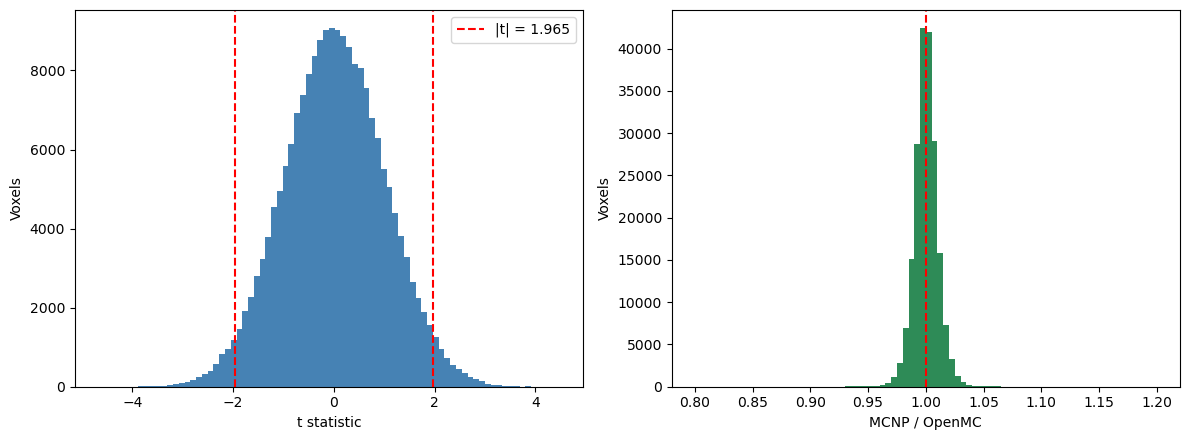

In [14]:
fig, (ax_t, ax_r) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_t.hist(np.clip(t_scored, -6, 6), bins=80, color='steelblue')
ax_t.axvline(-t_crit, color='r', ls='--')
ax_t.axvline(t_crit, color='r', ls='--', label=f'|t| = {t_crit}')
ax_t.set_xlabel('t statistic')
ax_t.set_ylabel('Voxels')
ax_t.legend()

ax_r.hist(np.clip(r_scored, 0.8, 1.2), bins=80, color='seagreen')
ax_r.axvline(1.0, color='r', ls='--')
ax_r.set_xlabel('MCNP / OpenMC')
ax_r.set_ylabel('Voxels')

fig.tight_layout()
fig.savefig(f'TTest_{tally_name}.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
result = 'PASS' if frac_agree >= pass_fraction else 'FAIL'
with open('results.txt', 'w') as results_file:
    results_file.write(result + '\n')